In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(context='notebook', style='whitegrid', palette='deep', font='sans-serif', font_scale=1, color_codes=True, rc=None)

In [2]:
# hourly timeseries data of Germany in 2015
hourly = pd.read_csv('https://tubcloud.tu-berlin.de/s/nwCrNLrtL6LAN3W/download/time-series-lecture-2.csv', index_col=0, parse_dates=True)
hourly.head()

,load [GW],onwind [pu],offwind [pu],solar [pu],prices [€/MWh]
2015-01-01 00:00:00,41.151,0.1566,0.7030,0.0,NaN
2015-01-01 01:00:00,40.135,0.1659,0.6875,0.0,NaN
2015-01-01 02:00:00,39.106,0.1746,0.6535,0.0,NaN
2015-01-01 03:00:00,38.765,0.1745,0.6803,0.0,NaN
2015-01-01 04:00:00,38.941,0.1826,0.7272,0.0,NaN


In [3]:
hourly.describe()

,load [GW],onwind [pu],offwind [pu],solar [pu],prices [€/MWh]
count,8760.000000,8760.000000,8760.000000,8760.000000,8663.000000
mean,54.736992,0.205556,0.362993,0.122621,31.835717
std,9.890092,0.189632,0.292684,0.182637,12.482199
min,32.418000,0.000700,0.000000,0.000000,-79.940000
25%,46.381000,0.069100,0.095500,0.000000,25.020000
50%,54.384000,0.143100,0.298700,0.002100,30.680000
75%,63.865500,0.281725,0.587250,0.203625,39.920000
max,75.817000,0.965900,0.985600,0.813400,99.770000


In [4]:
col_with_nan = hourly.isna().any()
print(col_with_nan)

# returns a DataFrame containing only rows with at least one NaN
rows_with_nan = hourly[hourly.isna().any(axis=1)]   
rows_with_nan

load [GW]         False
onwind [pu]       False
offwind [pu]      False
solar [pu]        False
prices [€/MWh]     True
dtype: bool


,load [GW],onwind [pu],offwind [pu],solar [pu],prices [€/MWh]
2015-01-01 00:00:00,41.151,0.1566,0.7030,0.0,NaN
2015-01-01 01:00:00,40.135,0.1659,0.6875,0.0,NaN
2015-01-01 02:00:00,39.106,0.1746,0.6535,0.0,NaN
2015-01-01 03:00:00,38.765,0.1745,0.6803,0.0,NaN
2015-01-01 04:00:00,38.941,0.1826,0.7272,0.0,NaN
...,...,...,...,...,...
2015-01-04 20:00:00,48.877,0.2732,0.4905,0.0,NaN
2015-01-04 21:00:00,48.808,0.2536,0.5374,0.0,NaN
2015-01-04 22:00:00,46.024,0.2400,0.5724,0.0,NaN
2015-01-04 23:00:00,42.658,0.2387,0.5799,0.0,NaN


In [5]:
# fill missing NAN with values observed 6 days ahead
n = 144  # 6 days * 24 hours

hourly['prices [€/MWh]'] = hourly['prices [€/MWh]'].fillna(hourly['prices [€/MWh]'].shift(-n))
col_with_nan = hourly.isna().any()
col_with_nan

load [GW]         False
onwind [pu]       False
offwind [pu]      False
solar [pu]        False
prices [€/MWh]    False
dtype: bool

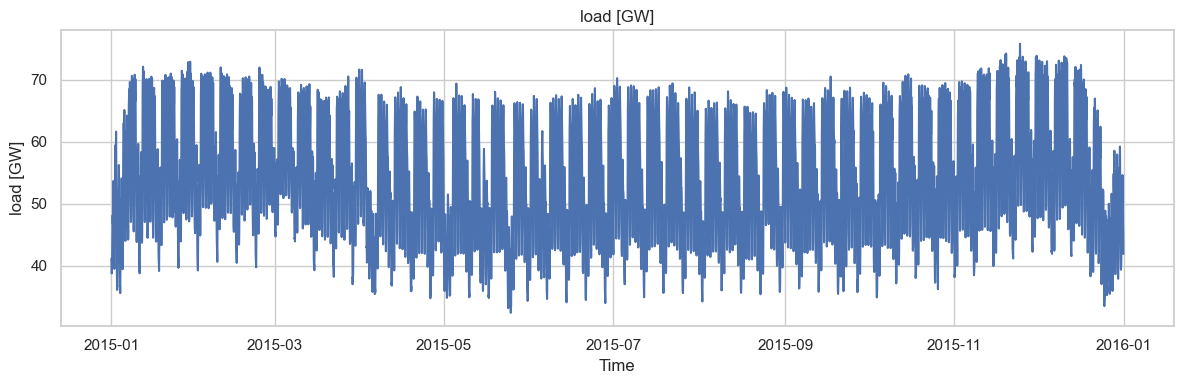

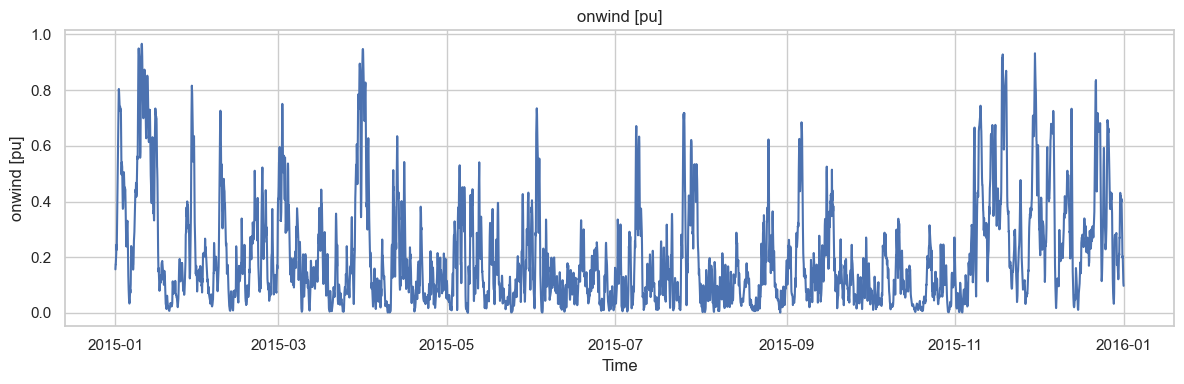

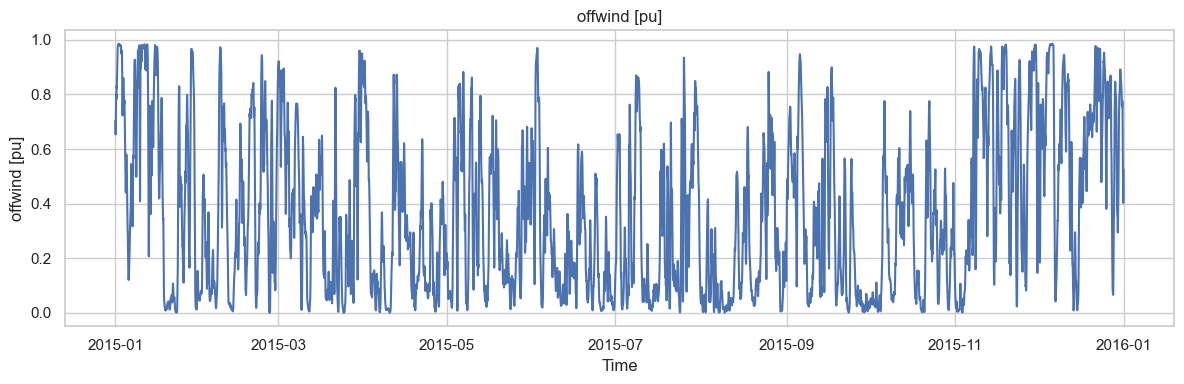

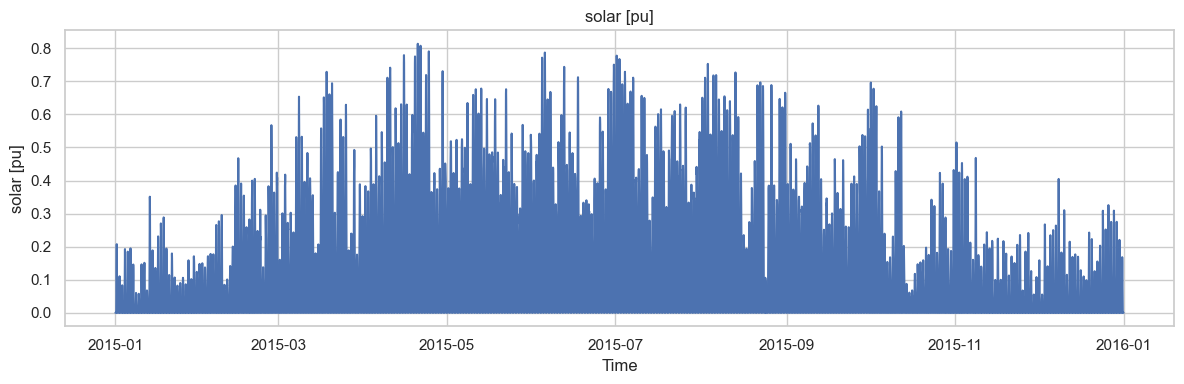

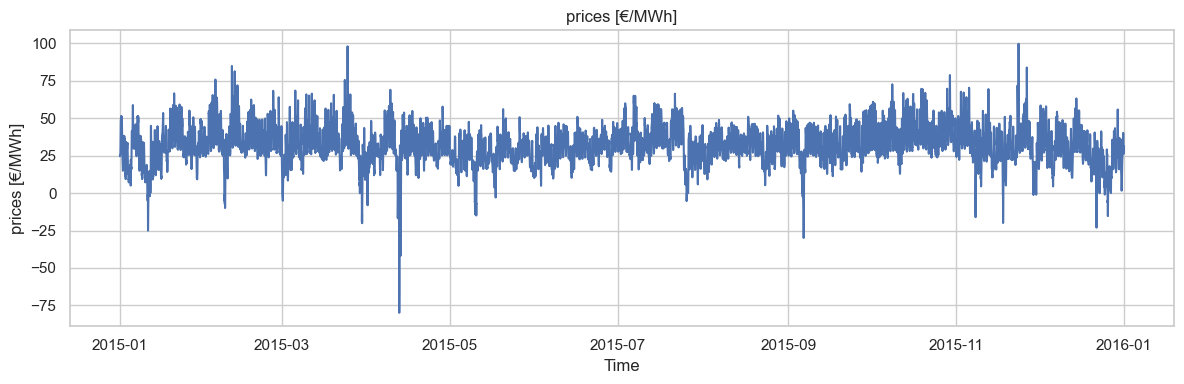

In [6]:
# hourly time series for the full year
for col in hourly.columns:
    plt.figure(figsize=(12, 4))
    plt.plot(hourly.index, hourly[col])
    plt.title(col)
    plt.xlabel("Time")
    plt.ylabel(col)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

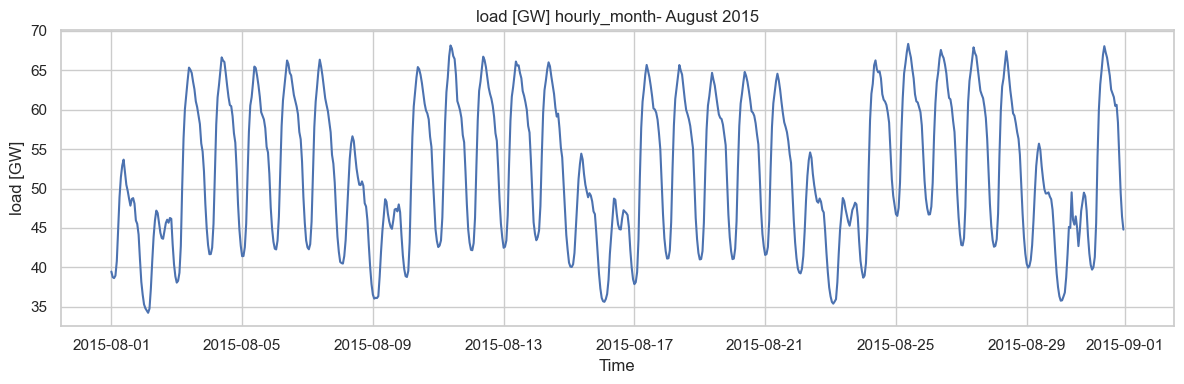

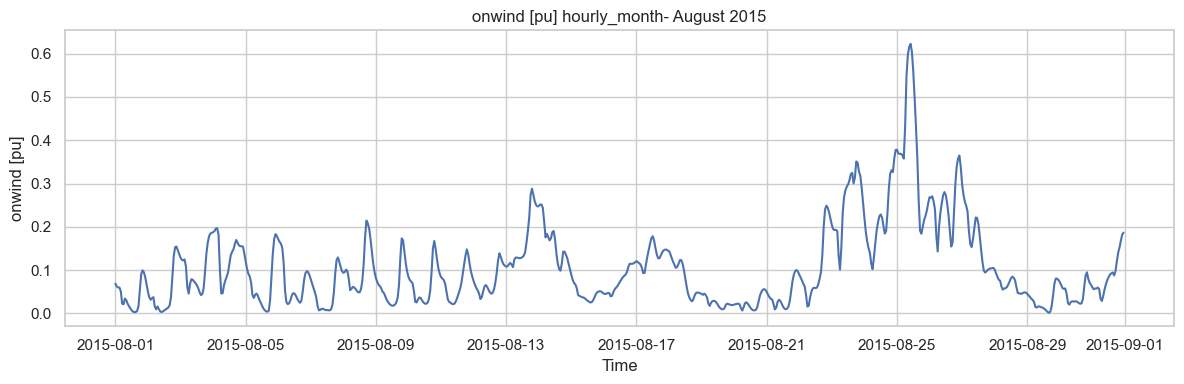

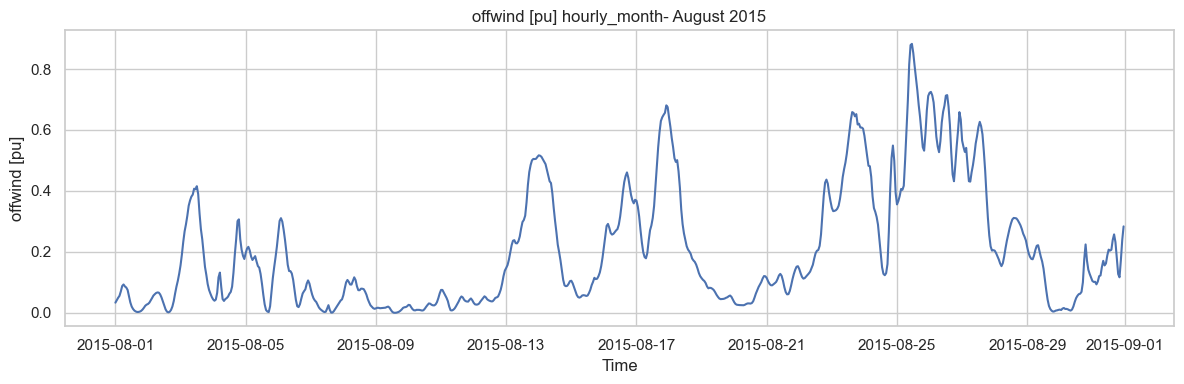

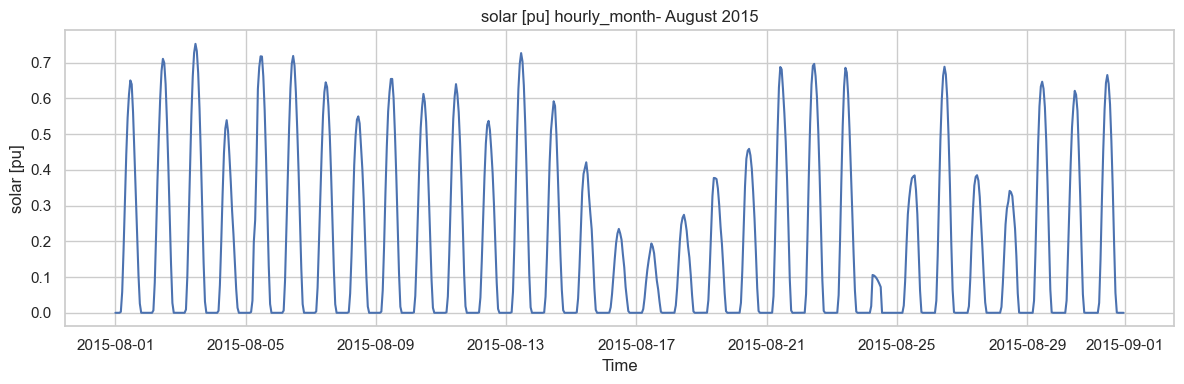

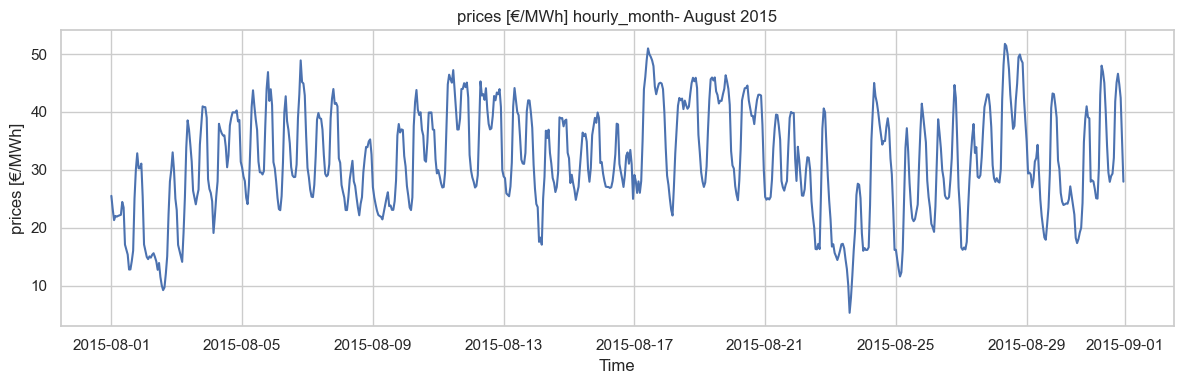

In [7]:
# hourly time series for specific month
hourly_month = hourly.loc["2015-08"]

for col in hourly_month.columns:
    plt.figure(figsize=(12, 4))
    plt.plot(hourly_month.index, hourly_month[col])
    plt.title(f"{col} hourly_month- August 2015")
    plt.xlabel("Time")
    plt.ylabel(col)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [8]:
# resampling the series to daily, weekly and monthly
daily = hourly.resample("D").mean()
weekly = hourly.resample("W").mean()
monthly = hourly.resample("ME").mean()

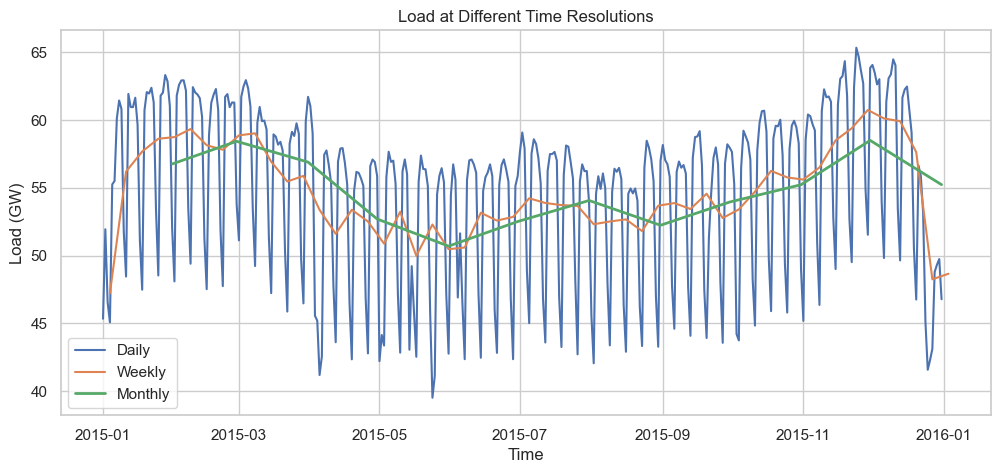

In [9]:
plt.figure(figsize=(12,5))

#plt.plot(hourly.index, hourly["load [GW]"], alpha=0.3, label="Hourly")
plt.plot(daily.index, daily["load [GW]"], label="Daily")
plt.plot(weekly.index, weekly["load [GW]"], label="Weekly")
plt.plot(monthly.index, monthly["load [GW]"], linewidth=2, label="Monthly")

plt.title("Load at Different Time Resolutions")
plt.xlabel("Time")
plt.ylabel("Load (GW)")
plt.legend()
plt.grid(True)

plt.show()

### On-shore Wind duration curve

In [10]:
hourly.columns

Index(['load [GW]', 'onwind [pu]', 'offwind [pu]', 'solar [pu]',
       'prices [€/MWh]'],
      dtype='object')

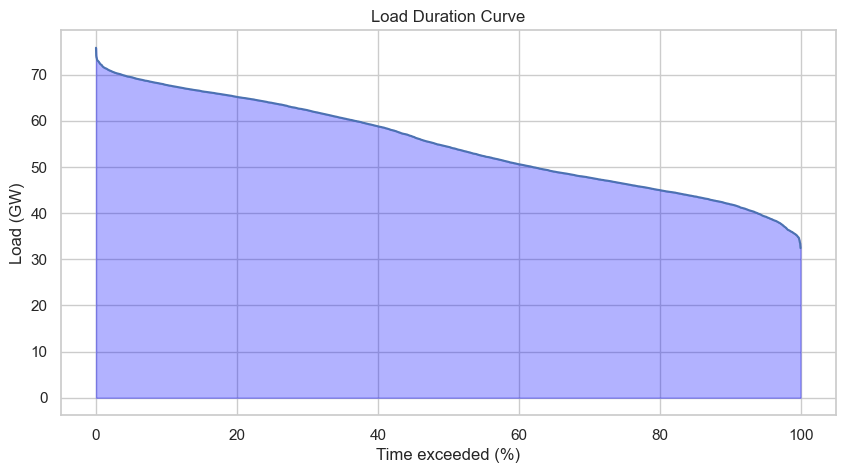

In [11]:
load = hourly["load [GW]"] 
load_sorted = load.sort_values(ascending=False)
load_sorted = load_sorted.reset_index(drop=True)

x = np.arange(len(load_sorted)) / len(load_sorted) * 100

plt.figure(figsize=(10,5))
plt.plot(x, load_sorted)
plt.fill_between(x, load_sorted, 0, alpha=0.3, color='blue', label='Area')


plt.xlabel("Time exceeded (%)")
plt.ylabel("Load (GW)")
plt.title("Load Duration Curve")
plt.grid(True)
plt.show()

### FFT of the time series

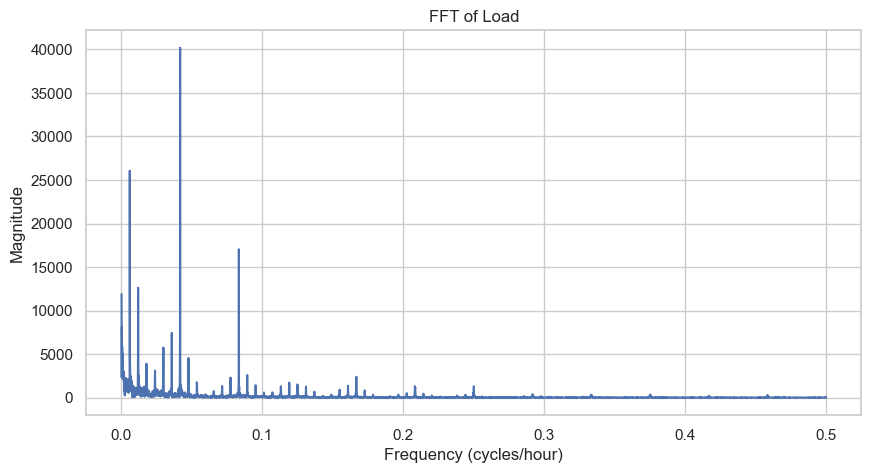

In [12]:
fft = np.fft.fft(load)
freq = np.fft.fftfreq(len(load), d=1)   # Frequency axis d = 1 hour sampling interval

mask = freq > 0 # prevents mirror image

plt.figure(figsize=(10,5))
plt.plot(freq[mask], np.abs(fft)[mask])

plt.xlabel("Frequency (cycles/hour)")
plt.ylabel("Magnitude")
plt.title("FFT of Load")
plt.grid(True)
plt.show()

In [13]:
hourly.to_csv('../data/hourly.csv', index=False)